# 3- Exploring some of the features to be used

- Fixations: count, duration (mean/std/max/min)
- Saccades: count, peak_veocity, amplitude (mean/max/min/std), duration (mean/std/max/min)
- Blinks: count, mean duration
- Pupil: LHIPA 

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import cognitive_models.preprocessing as cwpre
import cognitive_models.features as cwfeat
import cognitive_models.interpolate as cwinterp
import cognitive_models.pupil_utils as cwpupil
from importlib import reload
reload(cwpupil)
reload(cwinterp)
reload(cwpre)
reload(cwfeat)

COLET_DATASET_DIR = Path(cwpre.__file__).parents[2] / "datasets" / "COLET_CSV"
PARTICIPANTS = list(range(1, 48)) # Participants 1 to 10
PARTICIPANTS.remove(6) # Bad data
EXPERIMENTS = [1,2,3,4]

### A. Getting all the needed features

In [2]:
# 1- Load all required data
all_eye_data = cwpre.load_colet_data(COLET_DATASET_DIR, PARTICIPANTS, EXPERIMENTS)

print(f"Loaded eye-tracking data for {len(PARTICIPANTS)} participants and {len(EXPERIMENTS)} experiments. Total records: {len(all_eye_data)}")

There are 1 non matching timestamp_sec within the limits
Final merged dataset has 8184 records at 240 Hz
Final merged and resampled dataset has 2028 records at 60 Hz
There are 1 non matching timestamp_sec within the limits
Final merged dataset has 6866 records at 240 Hz
Final merged and resampled dataset has 1709 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 17301 records at 240 Hz
Final merged and resampled dataset has 4285 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 9246 records at 240 Hz
Final merged and resampled dataset has 2290 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 10159 records at 240 Hz
Final merged and resampled dataset has 2505 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 7113 records at 240 Hz
Final merged and resampled dataset has 1769 records at 60 Hz
Th

In [3]:
# Lets check integrity of the data
all_eye_data.columns
all_eye_data.groupby(['subject_id', 'task_id'])['cl_class'].value_counts().sort_index().head()

subject_id  task_id  cl_class
1           1        low         2028
            2        medium      1709
            3        high        4285
            4        medium      2290
2           1        low         2505
Name: count, dtype: int64

In [155]:
import tqdm
all_eye_data_grouped = all_eye_data.groupby(['subject_id', 'task_id'])
# Extract all window features
Fs = 60
WINDOW_N = 300 # 5 seconds at 60Hz
WINDOW_STEP = 100
SKIP_EDGE_SAMPLES = Fs # first & last second are discarded

features_df = pd.DataFrame()
for (subject_id, task_id), group_df in tqdm.tqdm(all_eye_data_grouped, desc="Extracting features"):
    feature_rows = []
    # Discard edge samples
    group_df = group_df.iloc[SKIP_EDGE_SAMPLES:-SKIP_EDGE_SAMPLES].sort_values('timestamp_sec')
    
    # Extract features in sliding windows
    for start in range(WINDOW_N, len(group_df), WINDOW_STEP):
        window_df = group_df.iloc[start - WINDOW_N:start].reset_index(drop=True)
        window_df, blink_df = cwpre.preprocess_colet_data(window_df, verbose=False) # Add derived columns
        features = cwfeat.extract_window_features(window_df, blink_df, ivt_threshold=45, min_fixation_duration=55, verbose=False)
        features['subject_id'] = subject_id
        features['task_id'] = task_id
        features['cl_class'] = window_df['cl_class'].iloc[0] # Class is the same for a given task
        feature_rows.append(features)
    
    features_df = pd.concat([features_df, pd.DataFrame(feature_rows)], ignore_index=True)

print(f"Extracted features for {len(features_df)} windows.")

Extracting features: 100%|██████████| 184/184 [07:05<00:00,  2.31s/it]

Extracted features for 4715 windows.


In [156]:
# Check what is the issue with the NaNs
display(features_df[features_df.isna().any(axis=1)].head())
features_df_transformed = features_df.copy()
features_df_transformed.dropna(inplace=True)

,fixations_count,fixations_duration_mean,fixations_duration_max,fixations_duration_min,fixations_duration_std,saccades_count,saccades_peak_velocity_mean,saccades_amplitude_mean,saccades_amplitude_max,saccades_amplitude_min,...,saccades_duration_max,saccades_duration_min,saccades_duration_std,blinks_count,blinks_duration_mean,pupil_lhipa,pupil_ripa2,subject_id,task_id,cl_class
153,0,NaN,NaN,NaN,NaN,8,662.535218,28.593119,126.144446,0.174540,...,1667.00,16.67,564.811026,9,0.142621,4.213204,0.056072,2,4,high
258,0,NaN,NaN,NaN,NaN,1,951.169635,1.357589,1.357589,1.357589,...,200.04,200.04,0.000000,11,0.157607,4.012575,0.201215,3,3,medium
275,0,NaN,NaN,NaN,NaN,1,113.732126,0.388519,0.388519,0.388519,...,50.01,50.01,0.000000,7,0.178607,4.213204,0.029286,3,4,low
416,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3,0.116690,4.614462,0.017195,5,4,high
818,0,NaN,NaN,NaN,NaN,1,45.589005,1.116240,1.116240,1.116240,...,16.67,16.67,0.000000,4,0.175035,4.012575,0.015810,10,3,medium


Let's check the distribtuion of the label classes 

<Axes: title={'center': 'Distribution of classes'}, xlabel='Cognitive Load Class', ylabel='Number of windows'>

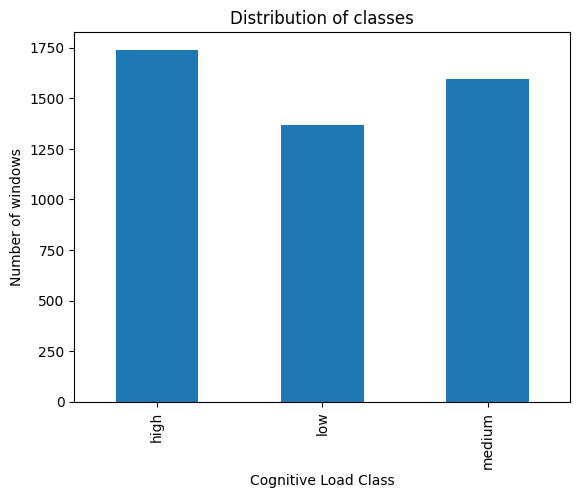

In [157]:
features_df_transformed.groupby('cl_class').count().plot(kind='bar', y='subject_id', title="Distribution of classes", legend=False, ylabel="Number of windows", xlabel="Cognitive Load Class")

As one can see, classes look quite balanced, which is a good thing for training a classifier

Now let's explore the distribution of the LHIPA metric.

As a reminder, it is related to a count of the number of spike/sec over the defined time window

In [97]:
features_df_transformed['pupil_lhipa'].describe()

count    913.000000
mean       4.672975
std        0.369081
min        3.287014
25%        4.460947
50%        4.695734
75%        4.930521
max        5.634881
Name: pupil_lhipa, dtype: float64

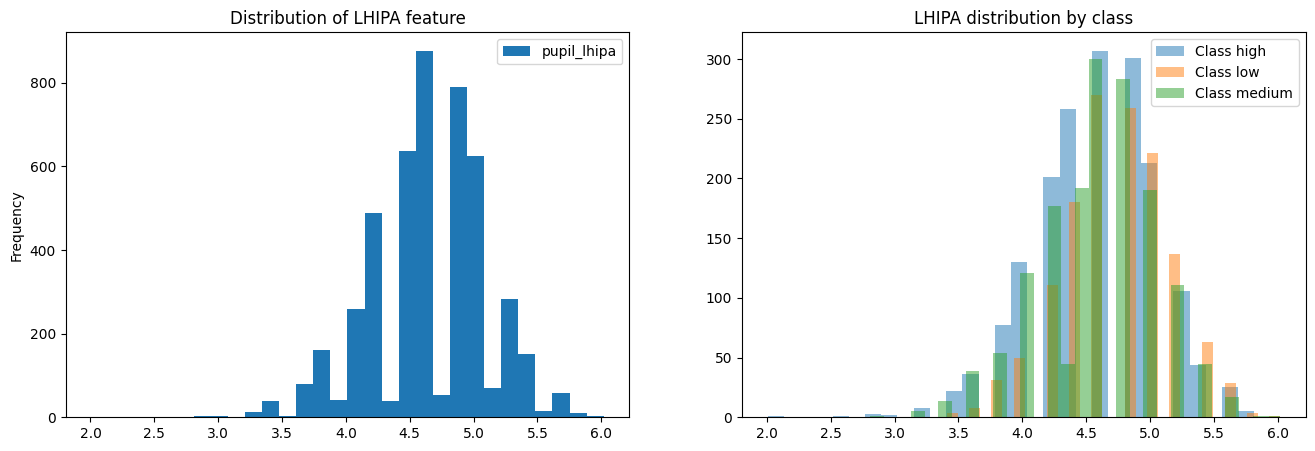

In [158]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))
features_df_transformed.plot(y='pupil_lhipa', kind='hist', bins=30, title='Distribution of LHIPA feature', ax=axs[0])
grouped_df = features_df_transformed.groupby('cl_class')
for cl_class, group in grouped_df:
    axs[1].hist(group['pupil_lhipa'], bins=30, alpha=0.5, label=f'Class {cl_class}')
axs[1].set_title('LHIPA distribution by class')
axs[1].legend()

<Axes: title={'center': 'pupil_lhipa'}, xlabel='Cognitive Load Class', ylabel='LHIPA'>

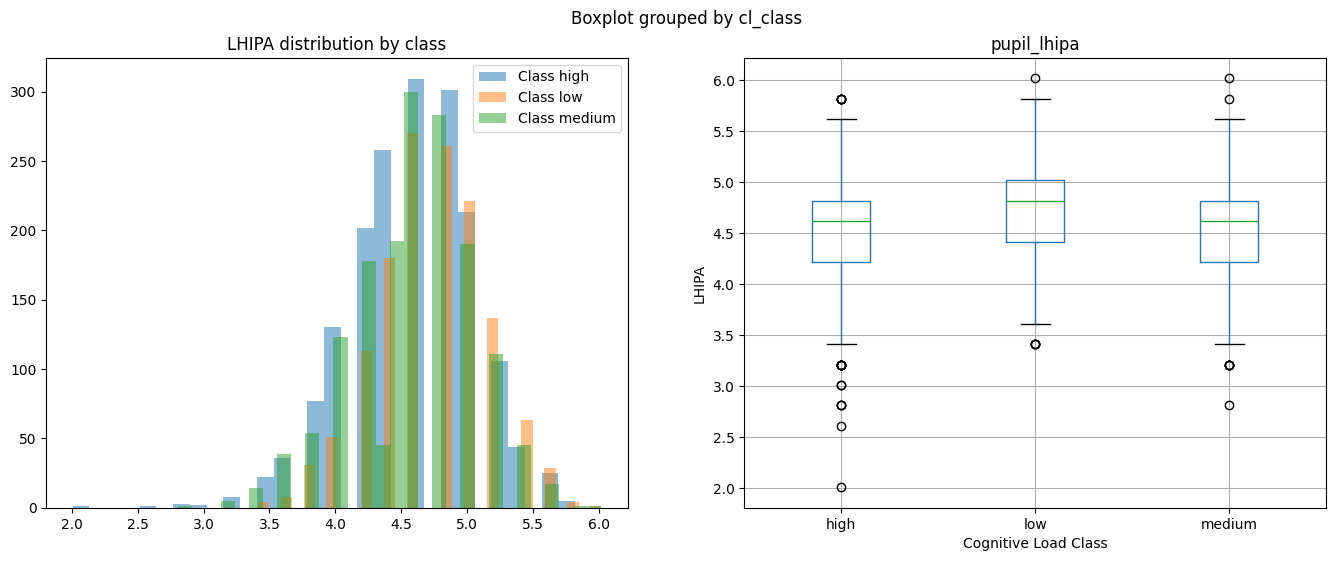

In [159]:
# Have box plots for the 3 classes on the same plot (x axis is class, y axis is LHIPA)
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
grouped_df = features_df.groupby('cl_class')
for cl_class, group in grouped_df:
    axs[0].hist(group['pupil_lhipa'], bins=30, alpha=0.5, label=f'Class {cl_class}')
axs[0].legend()
axs[0].set_title('LHIPA distribution by class')
features_df.boxplot(column='pupil_lhipa', by='cl_class', ax=axs[1], ylabel='LHIPA', xlabel='Cognitive Load Class')


In [160]:
# Lets perform a ttest to see if the difference in LHIPA between classes is significant
from scipy.stats import ttest_ind
class_0 = features_df[features_df['cl_class'] == 'low']['pupil_lhipa']
class_1 = features_df[features_df['cl_class'] == 'medium']['pupil_lhipa']
class_2 = features_df[features_df['cl_class'] == 'high']['pupil_lhipa']
print(f"Number of windows in low class: {len(class_0)}, medium class: {len(class_1)}, high class: {len(class_2)}")
t_stat, p_value = ttest_ind(class_0, class_1, equal_var=False)
print(f"T-test between low and medium classes: t-statistic={t_stat:.3f}, p-value={p_value:.5f}")
t_stat, p_value = ttest_ind(class_0, class_2, equal_var=False)
print(f"T-test between low and high classes: t-statistic={t_stat:.3f}, p-value={p_value:.5f}")
t_stat, p_value = ttest_ind(class_1, class_2, equal_var=False)
print(f"T-test between medium and high classes: t-statistic={t_stat:.3f}, p-value={p_value:.5f}")

Number of windows in low class: 1373, medium class: 1599, high class: 1743
T-test between low and medium classes: t-statistic=9.169, p-value=0.00000
T-test between low and high classes: t-statistic=10.347, p-value=0.00000
T-test between medium and high classes: t-statistic=1.231, p-value=0.21825


Let's take a look at the Cohen's d effect size metric.

It tells you how much is the mean difference between two distributions in terms of std multiplier.
For example, if $C_d\approx 0.5$, then it means that the two distribution means are different at a scale of 0.5 the std.

| $C_d$ coeff | effect size |
|-------------|-------------|
| 0.2 | small
| 0.5 | Medium
| 0.8 | Large

In [161]:
# Cohen's d effect size
def cohen_d(x, y):
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / dof)
    return (np.mean(y) - np.mean(x)) / pooled_std if pooled_std > 0 else 0

d_low_medium = cohen_d(class_0, class_1)
d_low_high = cohen_d(class_0, class_2)
d_medium_high = cohen_d(class_1, class_2)
print(f"Cohen's d effect size between low and medium classes: {d_low_medium:.3f}")
print(f"Cohen's d effect size between low and high classes: {d_low_high:.3f}")
print(f"Cohen's d effect size between medium and high classes: {d_medium_high:.3f}")


Cohen's d effect size between low and medium classes: -0.335
Cohen's d effect size between low and high classes: -0.367
Cohen's d effect size between medium and high classes: -0.043


#### What about this new RIPA2 "real-time" pupil frequency metric

In [162]:
features_df_transformed['pupil_ripa2'].describe()

count    4704.000000
mean        0.056454
std         0.122094
min         0.000257
25%         0.004953
50%         0.012291
75%         0.030746
max         0.987331
Name: pupil_ripa2, dtype: float64

<Axes: title={'center': 'pupil_ripa2'}, xlabel='Cognitive Load Class', ylabel='RIPA2'>

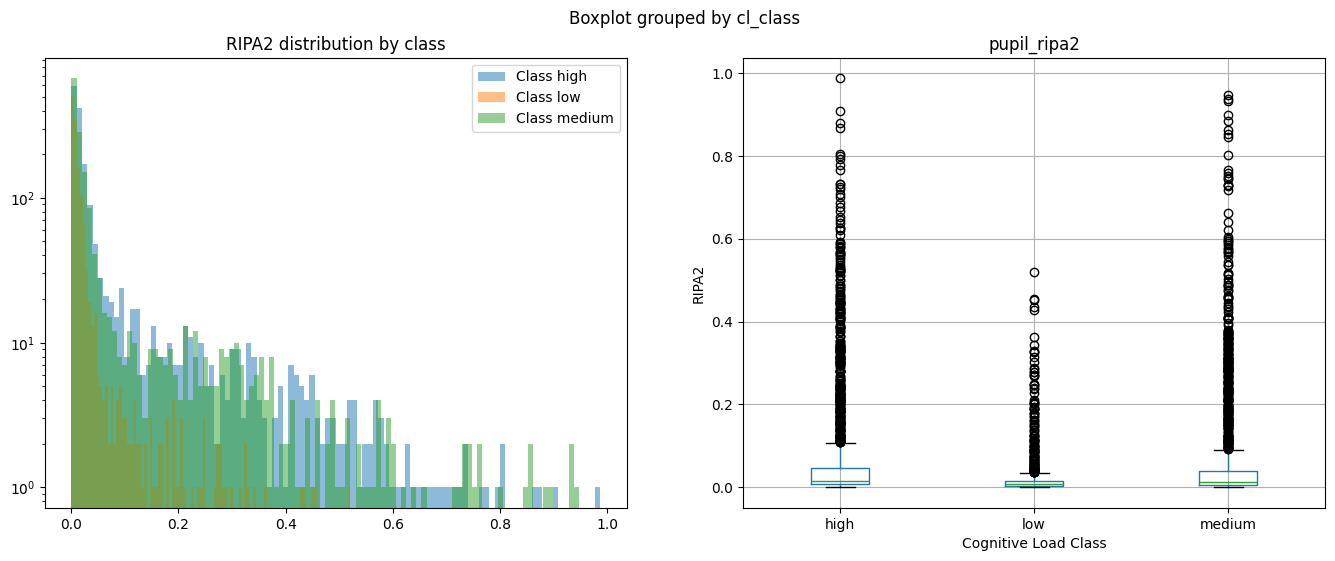

In [163]:
# Have box plots for the 3 classes on the same plot (x axis is class, y axis is LHIPA)
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
grouped_df = features_df.groupby('cl_class')
for cl_class, group in grouped_df:
    x = group['pupil_ripa2']
    axs[0].hist(x, bins=100, alpha=0.5, label=f'Class {cl_class}', log=True)
axs[0].legend()
axs[0].set_title('RIPA2 distribution by class')
features_df.boxplot(column='pupil_ripa2', by='cl_class', ax=axs[1], ylabel='RIPA2', xlabel='Cognitive Load Class')


In [164]:
class_0 = features_df_transformed[features_df_transformed['cl_class'] == 'low']['pupil_ripa2']
class_1 = features_df_transformed[features_df_transformed['cl_class'] == 'medium']['pupil_ripa2']
class_2 = features_df_transformed[features_df_transformed['cl_class'] == 'high']['pupil_ripa2']

print(f"Number of windows in low class: {len(class_0)}, medium class: {len(class_1)}, high class: {len(class_2)}")
t_stat, p_value = ttest_ind(class_0, class_1, equal_var=False)
print(f"T-test between low and medium classes: t-statistic={t_stat:.3f}, p-value={p_value:.5f}")
t_stat, p_value = ttest_ind(class_0, class_2, equal_var=False)
print(f"T-test between low and high classes: t-statistic={t_stat:.3f}, p-value={p_value:.5f}")
t_stat, p_value = ttest_ind(class_1, class_2, equal_var=False)
print(f"T-test between medium and high classes: t-statistic={t_stat:.3f}, p-value={p_value:.5f}")
d_low_medium = cohen_d(class_0, class_1)
d_low_high = cohen_d(class_0, class_2)
d_medium_high = cohen_d(class_1, class_2)
print(f"Cohen's d effect size between low and medium classes: {d_low_medium:.3f}")
print(f"Cohen's d effect size between low and high classes: {d_low_high:.3f}")
print(f"Cohen's d effect size between medium and high classes: {d_medium_high:.3f}")

Number of windows in low class: 1368, medium class: 1596, high class: 1740
T-test between low and medium classes: t-statistic=-12.637, p-value=0.00000
T-test between low and high classes: t-statistic=-14.261, p-value=0.00000
T-test between medium and high classes: t-statistic=-0.881, p-value=0.37838
Cohen's d effect size between low and medium classes: 0.439
Cohen's d effect size between low and high classes: 0.470
Cohen's d effect size between medium and high classes: 0.031


### TEMP

In [165]:
from sklearn import preprocessing
# z-normalize features
features_df_transformed = features_df.copy()
features_df_transformed.dropna(inplace=True) # Drop rows with NaNs for now
# features_df_transformed.drop(columns=['pupil_ripa2'], inplace=True)
feature_cols = [col for col in features_df_transformed.columns if col not in ['subject_id', 'task_id', 'cl_class']]
# feature_cols = ['pupil_lhipa', 'pupil_ripa2', 'fixations_count', 'saccades_count']

features_df_transformed.describe()

,fixations_count,fixations_duration_mean,fixations_duration_max,fixations_duration_min,fixations_duration_std,saccades_count,saccades_peak_velocity_mean,saccades_amplitude_mean,saccades_amplitude_max,saccades_amplitude_min,...,saccades_duration_mean,saccades_duration_max,saccades_duration_min,saccades_duration_std,blinks_count,blinks_duration_mean,pupil_lhipa,pupil_ripa2,subject_id,task_id
count,4704.000000,4704.000000,4704.000000,4704.000000,4704.000000,4704.000000,4704.000000,4704.000000,4704.000000,4704.000000,...,4704.000000,4704.000000,4704.000000,4704.000000,4704.000000,4704.000000,4704.000000,4704.000000,4704.000000,4704.000000
mean,10.030612,376.222717,1019.892855,101.217802,319.305767,10.261267,165.567654,1.697170,7.517048,0.110904,...,82.854698,256.180761,21.025321,80.537739,1.041241,0.069660,4.621499,0.056454,24.533376,2.773810
std,3.650754,224.781418,574.174390,117.511648,244.531982,3.347920,114.184064,3.449883,19.873548,0.726332,...,124.261195,357.280026,70.441829,141.481536,1.563457,0.079690,0.453121,0.122094,13.521537,1.087236
min,1.000000,66.680000,83.350000,50.010000,0.000000,1.000000,49.416034,0.085159,0.173335,0.000000,...,16.670000,16.670000,0.000000,0.000000,0.000000,0.000000,2.006288,0.000257,1.000000,1.000000
25%,7.000000,247.668571,633.460000,50.010000,175.048224,8.000000,96.699282,0.825114,1.988714,0.008151,...,43.342000,83.350000,16.670000,21.102957,0.000000,0.000000,4.413833,0.004953,13.000000,2.000000
50%,10.000000,324.006587,883.510000,83.350000,258.268995,10.000000,124.086934,1.057141,2.302330,0.031314,...,54.556364,133.360000,16.670000,36.681064,0.000000,0.000000,4.614462,0.012291,24.000000,3.000000
75%,13.000000,427.863333,1250.250000,100.020000,386.514545,13.000000,190.943072,1.350870,3.226782,0.084873,...,77.793333,250.050000,16.670000,71.628894,2.000000,0.141695,5.015719,0.030746,37.000000,4.000000
max,23.000000,3100.620000,4667.600000,3100.620000,3123.679561,22.000000,999.434757,86.645808,179.660264,32.781253,...,4050.810000,4434.220000,4050.810000,2887.930160,11.000000,0.283390,6.018863,0.987331,47.000000,4.000000


In [166]:
from sklearn.model_selection import train_test_split, ShuffleSplit, cross_val_score
from sklearn import svm, ensemble

features_df_transformed['labels'] = features_df_transformed['cl_class'].map({'low': 0, 'medium': 1, 'high': 2})

X = features_df_transformed[feature_cols].values
y = features_df_transformed['labels'].values

scaler = preprocessing.StandardScaler()
# scaler = preprocessing.MinMaxScaler()
scaler.fit(X)

train_x, test_x, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)
# Use cross-validation to create a validation set from the training set
cv = ShuffleSplit(n_splits=5, test_size=0.25, random_state=42)

print(f"Training set size: {len(train_x)}, Test set size: {len(test_x)}")

train_x_transformed = scaler.transform(train_x)
model = svm.LinearSVC()
# model = ensemble.RandomForestClassifier(n_estimators=100, random_state=42)
score = cross_val_score(model, train_x_transformed, train_y, cv=cv)
model.fit(train_x_transformed, train_y)
train_acc = model.score(train_x_transformed, train_y)
print(f"Train Accuracy: {train_acc:.2f}, Cross-validation Score: {score.mean():.2f} (+/- {score.std() * 2:.2f})")
print("SVC coeffs classes:")
# coeffs = [pd.Series(model.coef_[i], index=feature_cols).sort_values(ascending=False) for i in range(len(model.coef_))]
# coeffs_df = pd.DataFrame({f'class_{i}': coeffs[i] for i in range(len(model.coef_))})
# display(coeffs_df)

Training set size: 3763, Test set size: 941
Train Accuracy: 0.48, Cross-validation Score: 0.47 (+/- 0.01)
SVC coeffs classes:


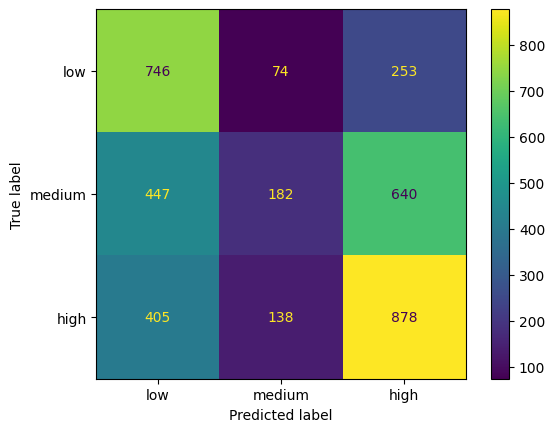

In [167]:
# Lets show the confusion matrix for the 3 classes (on validation set)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

val_y_pred = model.predict(train_x_transformed)
cm = confusion_matrix(train_y, val_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['low', 'medium', 'high'])
disp.plot()